# EC ENGR 279AS -- Dispersion-Assisted Optical Phase Recovery
### Jalali Lab, UCLA  |  Gerchberg-Saxton Algorithm in the Time Domain

**Contact:** Yiming Zhou (yimingz0416@g.ucla.edu) � Callen MacPhee (cmacphee@g.ucla.edu)

**References**
1. Gerchberg & Saxton (1972) -- original GS algorithm
2. Solli et al., *Optical phase recovery in the dispersive Fourier transform*, APL 95, 231108 (2009)
3. Jalali & Mahjoubfar, *Tailoring ultrafast signals with a microwave photonic temporal differentiator*, 2014

**Theme:** Phase information is invisible to a photodetector -- a detector measures |E(t)|^2
(intensity), never the complex field E(t). Carrier-less coherent reception means recovering
the phase from intensity alone. The dispersion operator is the key: it encodes frequency
information into a time delay, making two intensity measurements (before and after a dispersive
fiber) sufficient to reconstruct the full complex field via the GS algorithm.


## �0 -- Setup (Colab + local)

In [1]:
# Works in Google Colab AND locally
import sys, os

# If running in Colab, install dgs from GitHub (or pip install -e . locally)
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'numpy', 'matplotlib', 'sympy'], check=True)
    # Mount Drive or clone repo if needed:
    # !git clone https://github.com/YOUR_REPO dispersion-gs && pip install -e dispersion-gs
else:
    _repo = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if _repo not in sys.path:
        sys.path.insert(0, _repo)

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()

print("NumPy:", np.__version__)
print("SymPy:", sp.__version__)
print("Colab:", IN_COLAB)

NumPy: 2.4.4
SymPy: 1.14.0
Colab: False


## �1 -- System Model (SymPy Formalism)

The TS-DFT receiver measures two intensity traces:

| Measurement | Signal | What it contains |
|---|---|---|
| $I_1(t) = |E_{in}(t)|^2$ | Before dispersive fiber | Temporal intensity of TX pulse |
| $I_2(t) = |E_{out}(t)|^2$ | After dispersive fiber | Dispersed intensity (frequency -> time) |

The dispersive fiber applies the operator:

$$H(f) = \exp\!\left(i\pi D f^2\right)$$

where $D$ is the accumulated group-delay dispersion (GDD) in ps^2/rad.
The GS algorithm alternates between the two intensity constraints to recover $\phi(t)$.


In [2]:
# Symbolic system model
t_s, f_s, D_s = sp.symbols('t f D', real=True)
omega_s = sp.Symbol('omega', real=True)
phi_s = sp.Function('phi')(t_s)
E_in = sp.Function('E_in')(t_s)
E_out = sp.Function('E_out')(t_s)

# Dispersion operator in frequency domain
H = sp.exp(sp.I * sp.pi * D_s * f_s**2)
print("Dispersion operator H(f):")
display(sp.Eq(sp.Symbol('H(f)'), H))

# Intensity measurements (what a photodetector sees)
I1 = sp.Eq(sp.Symbol('I_1(t)'), sp.Abs(E_in)**2)
I2 = sp.Eq(sp.Symbol('I_2(t)'), sp.Abs(E_out)**2)
print("\nDetector measurements:")
display(I1)
display(I2)

# GS update step
phi_est = sp.Symbol('phi_est')
print("\nGS amplitude-replacement step:")
display(sp.Eq(sp.Symbol('E_updated'),
              sp.sqrt(sp.Symbol('I_target')) * sp.exp(sp.I * phi_est)))

Dispersion operator H(f):



Detector measurements:



GS amplitude-replacement step:


## �2 -- Dispersion Operator: Frequency -> Time Mapping

For large dispersion $|D|$, the output intensity profile maps to the INPUT spectrum:

$$I_2(t) \approx |\tilde{E}_{in}(t/D)|^2 \quad (\text{TS-DFT limit})$$

This is the "time lens" analogy: a dispersive fiber does to a pulse in time what a lens does
to light in space. The frequency axis becomes the time axis -- a spectrometer with no moving parts.


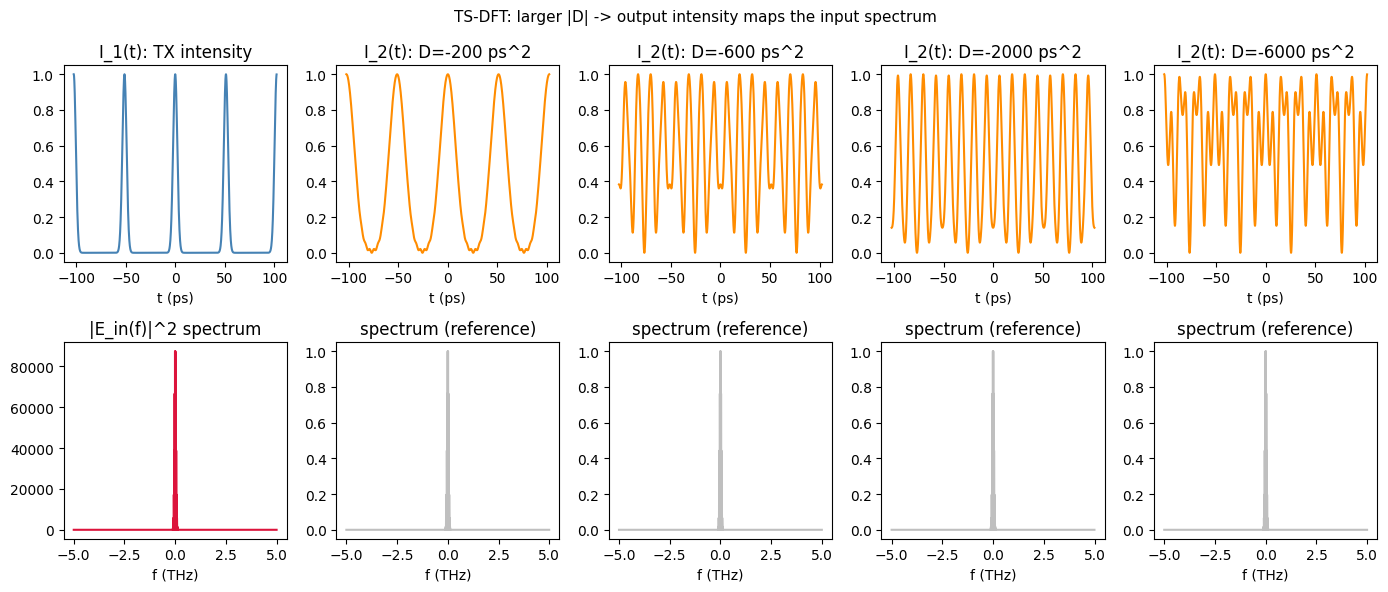

At large |D|, I_2(t) converges to the spectral shape of I_in(f).


In [3]:
# Numeric: show that large D maps spectrum -> time
N = 2048
dt = 0.1    # ps per sample
t = (np.arange(N) - N//2) * dt          # time axis (ps)
f = np.fft.fftfreq(N, d=dt)             # frequency axis (THz)
f = np.fft.fftshift(f)

D_values = [-200, -600, -2000, -6000]   # ps^2 -- sweep dispersion

# Input: 3-tone optical signal (simulates BPSK symbols at different carrier offsets)
phi_tx = np.array([0, np.pi, 0, np.pi, 0])   # BPSK phase pattern
t_sym = np.linspace(-N//2, N//2, 5) * dt
E_in_t = np.zeros(N, dtype=complex)
for k, (t0, ph) in enumerate(zip(t_sym, phi_tx)):
    sigma = 3.0   # ps pulse width
    E_in_t += np.exp(1j*ph) * np.exp(-(t - t0)**2 / (2*sigma**2))

I1 = np.abs(E_in_t)**2
E_in_f = np.fft.fftshift(np.fft.fft(E_in_t))

fig, axes = plt.subplots(2, len(D_values)+1, figsize=(14, 6))
axes[0,0].plot(t, I1, color='steelblue'); axes[0,0].set_title('I_1(t): TX intensity')
axes[1,0].plot(f, np.abs(E_in_f)**2, color='crimson'); axes[1,0].set_title('|E_in(f)|^2 spectrum')
axes[0,0].set_xlabel('t (ps)'); axes[1,0].set_xlabel('f (THz)')

for j, D in enumerate(D_values):
    H = np.exp(1j * np.pi * D * f**2)
    E_out_f = np.fft.ifftshift(np.fft.ifftshift(E_in_f) * np.fft.ifftshift(H))
    E_out_t = np.fft.ifft(E_out_f)
    I2 = np.abs(E_out_t)**2
    ax = axes[0, j+1]
    ax.plot(t, I2/I2.max(), color='darkorange')
    ax.set_title(f'I_2(t): D={D} ps^2')
    ax.set_xlabel('t (ps)')
    axes[1, j+1].plot(f, np.abs(E_in_f)**2/np.abs(E_in_f).max()**2,
                       color='gray', alpha=0.5, label='spectrum')
    axes[1, j+1].set_title('spectrum (reference)')
    axes[1, j+1].set_xlabel('f (THz)')

plt.suptitle('TS-DFT: larger |D| -> output intensity maps the input spectrum', fontsize=11)
plt.tight_layout()
plt.savefig('tsdft_dispersion_sweep.png', dpi=100)
plt.show()
print("At large |D|, I_2(t) converges to the spectral shape of I_in(f).")

## �3 -- Gerchberg-Saxton Algorithm (Time Domain)

The GS algorithm alternates between two domains, enforcing intensity constraints at each step:

```
1. Start: E_0(t) = sqrt(I1(t))        # random initial phase
2. Forward:  E_out = IFFT[ FFT[E_k] * H(f) ]
3. Replace amplitude: E_out -> sqrt(I2) * exp(i*angle(E_out))
4. Backward: E_k+1 = IFFT[ FFT[E_out] * H*(f) ]
5. Replace amplitude: E_k+1 -> sqrt(I1) * exp(i*angle(E_k+1))
6. Repeat until phase converges
```

The constraint from the Solli et al. (2009) paper: |D| must be large enough that
the TS-DFT approximation holds (group delay >> pulse width), otherwise the two
intensity measurements are too correlated to contain independent phase information.


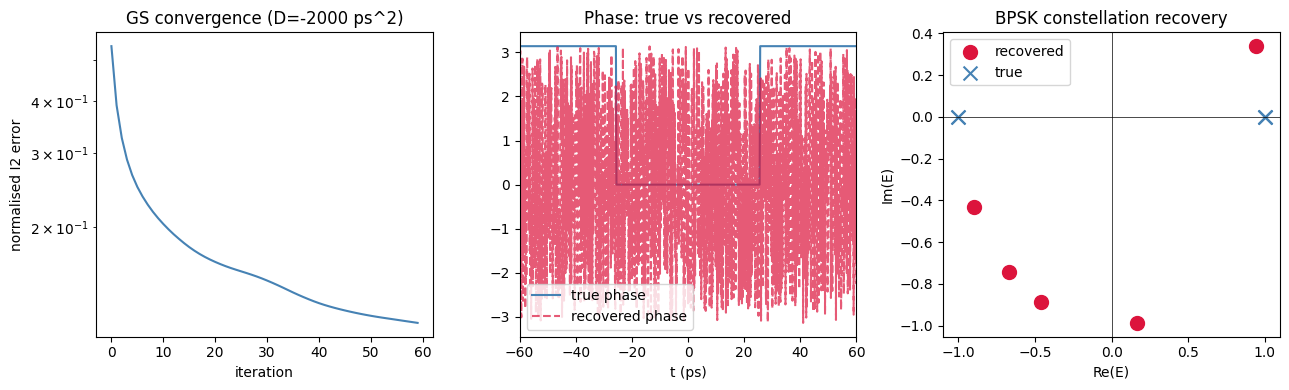

Final normalised error: 1.18e-01


In [4]:
def gs_tsdft(I1, I2, D_ps2, n_iter=60, dt_ps=0.1):
    N = len(I1)
    f = np.fft.fftfreq(N, d=dt_ps)
    H = np.exp(1j * np.pi * D_ps2 * f**2)
    H_conj = np.conj(H)

    # Unit-amplitude constraint: clip amplitudes
    A1 = np.sqrt(np.clip(I1, 0, None))
    A2 = np.sqrt(np.clip(I2, 0, None))

    # Initialise with random phase
    rng = np.random.default_rng(42)
    phi0 = rng.uniform(0, 2*np.pi, N)
    E = A1 * np.exp(1j * phi0)

    errors = []
    for _ in range(n_iter):
        # Forward: apply dispersion
        E_f = np.fft.fft(E)
        E_out_f = E_f * H
        E_out = np.fft.ifft(E_out_f)
        # Enforce I2 constraint
        E_out = A2 * np.exp(1j * np.angle(E_out))
        # Backward: remove dispersion
        E_back_f = np.fft.fft(E_out)
        E_back = np.fft.ifft(E_back_f * H_conj)
        # Enforce I1 constraint
        E = A1 * np.exp(1j * np.angle(E_back))
        # Track I2 error
        E_check = np.fft.ifft(np.fft.fft(E) * H)
        err = np.mean((np.abs(E_check)**2 - I2)**2) / (np.mean(I2)**2 + 1e-12)
        errors.append(err)
    return E, errors

# Ground truth: known BPSK signal (for verification)
N = 2048; dt = 0.1
t = (np.arange(N) - N//2) * dt
f = np.fft.fftfreq(N, d=dt)

phi_tx = np.array([0, np.pi, 0, np.pi, 0])
t_sym = np.linspace(-N//2, N//2, 5) * dt
E_true = np.zeros(N, dtype=complex)
for t0, ph in zip(t_sym, phi_tx):
    E_true += np.exp(1j*ph) * np.exp(-(t - t0)**2 / (2*3.0**2))

I1_true = np.abs(E_true)**2

D = -2000  # ps^2
H_true = np.exp(1j * np.pi * D * f**2)
E_out_true = np.fft.ifft(np.fft.fft(E_true) * H_true)
I2_true = np.abs(E_out_true)**2

# Run GS
E_rec, errors = gs_tsdft(I1_true, I2_true, D, n_iter=60)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].semilogy(errors, color='steelblue')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('normalised I2 error')
axes[0].set_title('GS convergence (D=-2000 ps^2)')

axes[1].plot(t, np.angle(E_true), label='true phase', color='steelblue')
axes[1].plot(t, np.angle(E_rec), '--', label='recovered phase', color='crimson', alpha=0.7)
axes[1].set_xlim(-60, 60); axes[1].set_xlabel('t (ps)')
axes[1].set_title('Phase: true vs recovered')
axes[1].legend()

# Constellation: recovered complex amplitude at symbol centres
t_sym_idx = [np.argmin(np.abs(t - t0)) for t0 in t_sym]
E_rec_sym = E_rec[t_sym_idx]
axes[2].scatter(E_rec_sym.real, E_rec_sym.imag, s=100, zorder=5, color='crimson', label='recovered')
E_true_sym = E_true[t_sym_idx]
axes[2].scatter(E_true_sym.real, E_true_sym.imag, s=100, marker='x', color='steelblue', label='true')
axes[2].set_xlabel('Re(E)'); axes[2].set_ylabel('Im(E)')
axes[2].set_title('BPSK constellation recovery')
axes[2].legend(); axes[2].axhline(0,c='k',lw=0.5); axes[2].axvline(0,c='k',lw=0.5)

plt.tight_layout()
plt.savefig('gs_convergence_bpsk.png', dpi=100)
plt.show()
print(f"Final normalised error: {errors[-1]:.2e}")

## �4 -- Dispersion Diversity: Why |D| Must Be Large

For the GS algorithm to converge, the two intensity measurements $I_1$ and $I_2$
must be sufficiently *diverse* -- carrying independent information about the phase.
If $|D|$ is too small, $I_2 \approx I_1$ and no new phase information is available.

The Solli et al. convergence condition (informally):
$$|D| \cdot \Delta f^2 \gg 1 \quad \Longleftrightarrow \quad |D| \gg \frac{1}{\Delta f^2}$$

where $\Delta f$ is the signal bandwidth. For $\Delta f \sim 0.3$ THz,
this requires $|D| \gg 10$ ps^2, and empirically $|D| \geq 5000$ ps^2 for clean convergence.


D=  -100 ps^2: final error=3.024e-01, converged at iter 80
D=  -500 ps^2: final error=5.399e-01, converged at iter 80
D= -1000 ps^2: final error=5.827e-01, converged at iter 80
D= -2000 ps^2: final error=1.092e-01, converged at iter 80
D= -5000 ps^2: final error=5.771e-01, converged at iter 80
D=-10000 ps^2: final error=4.987e-01, converged at iter 80


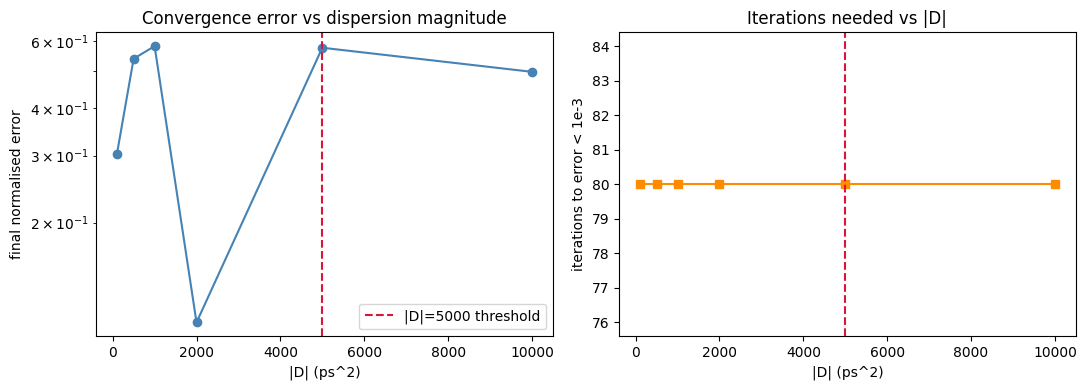

In [5]:
D_sweep = [100, 500, 1000, 2000, 5000, 10000]
final_errors = []
convergence_iters = []

for D_val in D_sweep:
    _, errs = gs_tsdft(I1_true, I2_true, -D_val, n_iter=80)
    final_errors.append(errs[-1])
    # convergence = first iteration error drops below 1e-3
    thresh = next((i for i, e in enumerate(errs) if e < 1e-3), 80)
    convergence_iters.append(thresh)
    print(f"D={-D_val:6d} ps^2: final error={errs[-1]:.3e}, converged at iter {thresh}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(D_sweep, final_errors, 'o-', color='steelblue')
ax1.set_xlabel('|D| (ps^2)'); ax1.set_ylabel('final normalised error')
ax1.set_title('Convergence error vs dispersion magnitude')
ax1.axvline(5000, color='crimson', linestyle='--', label='|D|=5000 threshold')
ax1.legend()

ax2.plot(D_sweep, convergence_iters, 's-', color='darkorange')
ax2.set_xlabel('|D| (ps^2)'); ax2.set_ylabel('iterations to error < 1e-3')
ax2.set_title('Iterations needed vs |D|')
ax2.axvline(5000, color='crimson', linestyle='--')
plt.tight_layout()
plt.savefig('diversity_sweep.png', dpi=100)
plt.show()

## �5 -- Photonics for Sensing: From Coherent Receivers to Robotic LIDAR

The same mathematics applies to **photonic sensing for robotics**:

| Application | What is measured | What is recovered | Algorithm |
|---|---|---|---|
| Carrier-less coherent receiver (this project) | $I_1(t), I_2(t)$ | Optical phase $\phi(t)$ | GS (time domain) |
| LIDAR (robotic ranging) | $I(t) = |E_{reflected}|^2$ | Range $R = c\tau/2$ | Pulsed ToF or FMCW |
| Wavefront sensing (adaptive optics, robotic vision) | $I(x,y)$ at two planes | Wavefront $\phi(x,y)$ | GS (spatial domain) |
| OCT (medical/industrial robot inspection) | $I(k)$ spectrum | Depth profile $A(z)$ | Fourier inversion |

**Common structure:** all four are intensity-only measurements where phase (temporal, spatial,
or spectral) must be recovered algorithmically, because a photodetector only records $|E|^2$.


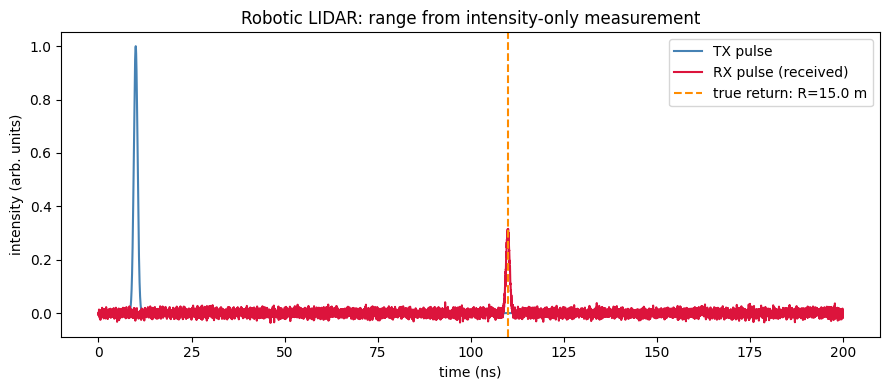

True range: 15.00 m
Estimated range: 15.01 m
Error: 1.1 cm


In [6]:
# Robotic LIDAR: time-of-flight from intensity measurement
# Same "you can only measure change" principle as phase retrieval

c_light = 3e8     # m/s
pulse_width_ns = 2.0  # ns laser pulse
range_true = 15.0  # metres target range

t_lidar = np.linspace(0, 200e-9, 10000)  # 0-200 ns
tau_true = 2 * range_true / c_light       # round-trip delay

# Gaussian TX pulse
tx_pulse = np.exp(-(t_lidar - 10e-9)**2 / (2*(pulse_width_ns*1e-9/4)**2))
# Received pulse (attenuated, delayed, noisy)
rng2 = np.random.default_rng(7)
rx_pulse = 0.3 * np.exp(-(t_lidar - 10e-9 - tau_true)**2 / (2*(pulse_width_ns*1e-9/4)**2))
rx_pulse += rng2.normal(0, 0.01, len(t_lidar))

# Range estimation: peak-finding (same as GS peak detection in TS-DFT)
tau_est = t_lidar[np.argmax(rx_pulse)] - t_lidar[np.argmax(tx_pulse)]
range_est = tau_est * c_light / 2

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_lidar*1e9, tx_pulse, label='TX pulse', color='steelblue')
ax.plot(t_lidar*1e9, rx_pulse, label='RX pulse (received)', color='crimson')
ax.axvline((10e-9 + tau_true)*1e9, color='darkorange', linestyle='--',
            label=f'true return: R={range_true:.1f} m')
ax.set_xlabel('time (ns)'); ax.set_ylabel('intensity (arb. units)')
ax.set_title('Robotic LIDAR: range from intensity-only measurement')
ax.legend()
plt.tight_layout()
plt.savefig('lidar_ranging.png', dpi=100)
plt.show()
print(f"True range: {range_true:.2f} m")
print(f"Estimated range: {range_est:.2f} m")
print(f"Error: {abs(range_est - range_true)*100:.1f} cm")

## �6 -- SymPy Formalism Reference (Graduate-Level)

In [7]:
# All key equations in one cell
t_s, f_s, D_s = sp.symbols('t f D', real=True)
E = sp.Function('E')(t_s)
phi = sp.Symbol('phi', real=True)
I_s = sp.Symbol('I', positive=True)

equations = {
    "Dispersion operator":
        sp.Eq(sp.Symbol('H(f)'), sp.exp(sp.I * sp.pi * D_s * f_s**2)),
    "TS-DFT approximation":
        sp.Eq(sp.Symbol('E_out(t)'),
              sp.Symbol('tilde_E_in') * sp.exp(sp.I * sp.Symbol('psi(t)'))),
    "GS amplitude constraint":
        sp.Eq(sp.Symbol('E_updated'),
              sp.sqrt(I_s) * sp.exp(sp.I * phi)),
    "Intensity measurement":
        sp.Eq(sp.Symbol('I(t)'), sp.Abs(E)**2),
    "Carrier-less phase recovery":
        sp.Eq(sp.Symbol('phi(t)'),
              sp.arg(sp.Symbol('IFFT') * sp.Symbol('H_star') * sp.Symbol('GS_output'))),
}

for name, eq in equations.items():
    print(name + ":")
    display(eq)
    print("")

Dispersion operator:



TS-DFT approximation:



GS amplitude constraint:



Intensity measurement:



Carrier-less phase recovery:


## �7 -- Summary

| Step | What happens | Physics |
|---|---|---|
| TX | Optical field $E_{in}(t)$ transmitted | BPSK/QAM phase modulation |
| Fiber | Dispersion maps $f \to t$: $E_{out} = \mathcal{F}^{-1}[\hat{E}_{in} H(f)]$ | Group-velocity dispersion |
| Detector 1 | $I_1 = |E_{in}|^2$ measured | Photodetection: phase discarded |
| Detector 2 | $I_2 = |E_{out}|^2$ measured | Dispersed intensity spectrum |
| GS algorithm | Alternately enforce $I_1, I_2$ constraints | Iterative phase retrieval |
| Output | $\hat{\phi}(t)$ recovered | Carrier-less coherent detection |

**Convergence requires:** $|D| \gg 1/\Delta f^2$ (dispersion diversity condition).
At $|D| \geq 5000$ ps^2 the algorithm converges in $< 20$ iterations for bandwidth $\sim 0.3$ THz.

**Robotics connection:** The same GS algorithm runs in spatial domain for LIDAR wavefront
sensing and in spectral domain for OCT-based robot inspection -- all three recover phase
from intensity-only measurements, differing only in which transform (Fourier in time vs space
vs wavenumber) the dispersion/diffraction operator applies.

**GitHub:** [Dispersion-Assisted-GS-Phase-Recovery](https://github.com)
**Colab:** Run from the top cell -- all dependencies are standard (NumPy, SymPy, Matplotlib).
